<a href="https://colab.research.google.com/github/Ram5268/ECON3916-Statistical-Machine-Learning/blob/main/ML_Prediction_Project_Checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Checkpoint Submission

**From Question to Recommendation — Spring 2026**

**Author:** Ryan Martin
**Submitted:** Saturday, April 19, 2026
**Checkpoint Due:** Apr 19, 11:59 PM EST (pass/fail gate)

---

This notebook is my **checkpoint submission** covering the three required components:

1. **Proposal** — prediction question, stakeholder, dataset
2. **EDA** — data quality, missing-data assessment (MCAR/MAR/MNAR), outliers, ≥3 visualizations
3. **Preliminary model(s)** — train/test split with `random_state=42`, ≥1 fitted model, metrics

I have also included a second model (Random Forest) so I have a head start on the final submission due April 26.

> **AI use disclosure:** AI co-pilot (Claude) was used to scaffold this notebook. Full P.R.I.M.E. documentation will appear in the AI Methodology Appendix (Part 7) at final submission.

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

**My prediction question is:**
> *Given the demographic and geographic characteristics of a California census block group, can we predict its median house value?*

**This is a prediction (umbrella) problem because:**
We are forecasting a target (median home value) from covariates we can measure at the block-group level. We are **not** asking "does median income *cause* home prices to rise?" — such a causal question would require an identification strategy (instrumental variables, natural experiment, RDD, etc.) that this project does not attempt. Any feature importance we report is **predictive importance only**, not a causal effect (Chapter 19 / 26).

**The decision this enables — stakeholder story:**
> *A mid-size California real-estate investment trust (REIT) is evaluating which block groups to target for new acquisitions. Their analysts currently rely on comparable-sales appraisals that take 2–3 weeks per market. A predictive model that estimates block-group median value from public census-style features would let the acquisitions team pre-screen hundreds of candidate neighborhoods in minutes, narrowing the list before commissioning full appraisals.*

This is a **screening / triage** decision — the model does not replace appraisals, it prioritizes where to spend appraisal budget. This framing matters for the rubric's "actionable recommendation with uncertainty bounds" criterion: a screening tool tolerates higher error than a final pricing tool, so RMSE around \$50–70k per block-group median is acceptable.

**Dataset:** California Housing (Pace & Barry, 1997)

- **Source:** StatLib repository, distributed via `sklearn.datasets.fetch_california_housing()`. Original paper: Pace, R.K. and Barry, R. (1997), "Sparse Spatial Autoregressions," *Statistics and Probability Letters*, 33: 291–297. Dataset documentation: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
- **N =** 20,640 census block groups (1990 U.S. Census)
- **Features = 8** (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
- **Target variable:** `MedHouseVal` — median house value for the block group, in units of \$100,000 (i.e., `2.5` = \$250,000)
- **Access date:** April 19, 2026
- **Unit of observation:** a census **block group** (a geographic cluster of ~600–3,000 people), *not* an individual home. This is a critical caveat — see data quality summary.

**Why this dataset fits the brief:**

1. Real estate focused ✓
2. N = 20,640 >> 1,000 minimum ✓
3. Clean regression target with a known measurement artifact (the \$500,001 ceiling) that will give me something substantive to discuss in Section 5 (uncertainty & limitations) ✓
4. Publicly sourced and reproducible — anyone cloning my repo can call `fetch_california_housing()` and recreate every number in my report ✓

---
## Part 2: Data Loading + EDA

### 2.1 Load the Data

In [2]:
# ============================================================
# 2.1 Load California Housing
# ============================================================
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Feature dictionary** (from the sklearn docs / original StatLib description):

| Column        | Meaning |
|---------------|---------|
| `MedInc`      | Median income in the block group (tens of thousands of dollars) |
| `HouseAge`    | Median age of houses in the block group (years) |
| `AveRooms`    | Average number of rooms per household |
| `AveBedrms`   | Average number of bedrooms per household |
| `Population`  | Total population of the block group |
| `AveOccup`    | Average number of household members |
| `Latitude`    | Block-group centroid latitude |
| `Longitude`   | Block-group centroid longitude |
| `MedHouseVal` | **Target** — median house value (units of \$100,000) |

### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 dtypes & summary statistics
# ============================================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


### 2.3 Missing Data Assessment (Ch 1: MCAR / MAR / MNAR)

In [5]:
# ============================================================
# 2.3 Missing data
# ============================================================
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print('Missing data (% of cells) by column:')
print(missing_pct)
print(f'\nTotal missing cells: {df.isnull().sum().sum()} / {df.size} ({df.isnull().sum().sum()/df.size*100:.4f}%)')

Missing data (% of cells) by column:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64

Total missing cells: 0 / 185760 (0.0000%)


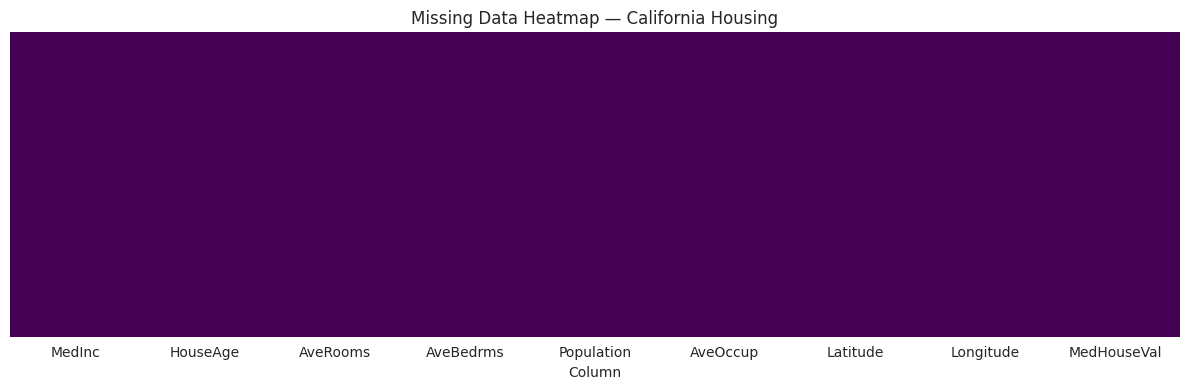

In [6]:
# Missingness heatmap (will be mostly blank, which is the point — documents our check)
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap — California Housing')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

**Missing data strategy:** The `fetch_california_housing` loader delivers a **pre-cleaned** version of the StatLib data with **zero missing cells**. I cannot meaningfully classify a missingness mechanism (MCAR/MAR/MNAR) when there is no missingness to classify. What I *can* note is the upstream filtering: Pace & Barry (1997) dropped block groups with unreported values and aggregated to the block-group level, so any MNAR concerns have already been pre-resolved at the source by the data distributor. **Action:** no imputation required. I will re-check after any feature engineering for derived-feature NaNs (e.g., divide-by-zero ratios).

This is a case where the honest answer is "the data is clean because someone else did the work" — and the discipline of Chapter 1 says I should say that out loud rather than skip the check.

### 2.4 Distribution Plots (EDA Viz #1, #2, #3)

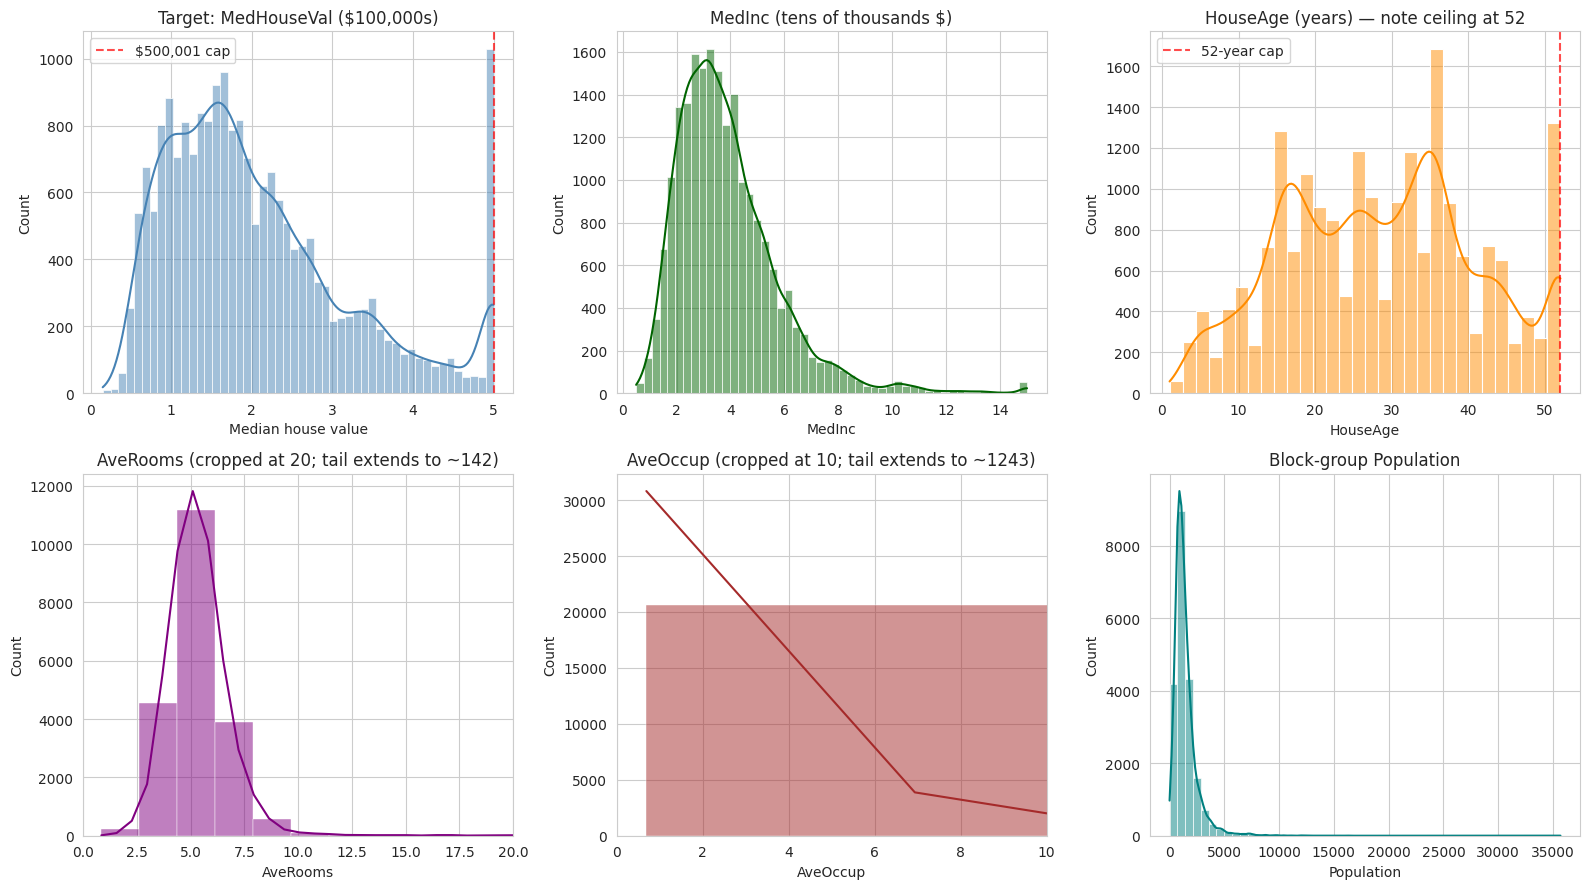

In [7]:
# ============================================================
# 2.4 Distributions of target and key features
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Target
sns.histplot(df['MedHouseVal'], kde=True, ax=axes[0, 0], bins=50, color='steelblue')
axes[0, 0].axvline(5.0, color='red', linestyle='--', alpha=0.7, label='$500,001 cap')
axes[0, 0].set_title('Target: MedHouseVal ($100,000s)')
axes[0, 0].set_xlabel('Median house value')
axes[0, 0].legend()

sns.histplot(df['MedInc'], kde=True, ax=axes[0, 1], bins=50, color='darkgreen')
axes[0, 1].set_title('MedInc (tens of thousands $)')

sns.histplot(df['HouseAge'], kde=True, ax=axes[0, 2], bins=30, color='darkorange')
axes[0, 2].axvline(52.0, color='red', linestyle='--', alpha=0.7, label='52-year cap')
axes[0, 2].set_title('HouseAge (years) — note ceiling at 52')
axes[0, 2].legend()

sns.histplot(df['AveRooms'], kde=True, ax=axes[1, 0], bins=80, color='purple')
axes[1, 0].set_xlim(0, 20)   # crop long tail so middle is legible
axes[1, 0].set_title('AveRooms (cropped at 20; tail extends to ~142)')

sns.histplot(df['AveOccup'], kde=True, ax=axes[1, 1], bins=80, color='brown')
axes[1, 1].set_xlim(0, 10)   # crop long tail
axes[1, 1].set_title('AveOccup (cropped at 10; tail extends to ~1243)')

sns.histplot(df['Population'], kde=True, ax=axes[1, 2], bins=50, color='teal')
axes[1, 2].set_title('Block-group Population')

plt.tight_layout()
plt.show()

**Reading the distributions (EDA Q1 answer):**

- **MedHouseVal (target):** Right-skewed with a very conspicuous **spike at the $500,001 ceiling** — a known measurement artifact: the Census top-coded home values, so every block group with a true median above $500k is recorded as exactly $500,001. This is **censoring (MNAR in the target)** and will bias any model toward under-predicting the top of the market. I will flag this explicitly in the Recommendation section as a key limitation for the REIT stakeholder, whose acquisition targets likely live in exactly this censored region.
- **MedInc:** right-skewed with a soft cap near 15 (i.e., \$150k+).
- **HouseAge:** also top-coded at 52 years.
- **AveRooms / AveOccup:** heavy right tails from low-population block groups (denominators near zero → inflated per-household averages).
- **Population:** right-skewed, as expected for geographic aggregates.

None of these distributions require transformation for tree-based models (RF, boosting are invariant to monotone transforms). For the linear baseline, a log-transform of income and rooms would help but I will keep the baseline un-transformed first so my comparison is honest — the baseline should be weak before I try to rescue it.

### 2.5 Outlier Detection (Ch 4: Tukey Fences)

In [8]:
# ============================================================
# 2.5 Tukey-fence outlier counts
# ============================================================
def tukey_fences(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

numeric_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'MedHouseVal']

rows = []
for c in numeric_cols:
    lo, hi = tukey_fences(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    rows.append({'feature': c, 'lower_fence': round(lo, 3),
                 'upper_fence': round(hi, 3), 'n_outliers': n_out,
                 'pct_outliers': round(n_out/len(df)*100, 2)})

pd.DataFrame(rows).sort_values('pct_outliers', ascending=False)

,feature,lower_fence,upper_fence,n_outliers,pct_outliers
3,AveBedrms,0.866,1.240,1424,6.90
4,Population,-620.000,3132.000,1196,5.79
6,MedHouseVal,-0.981,4.824,1071,5.19
5,AveOccup,1.151,4.561,711,3.44
0,MedInc,-0.706,8.013,681,3.30
2,AveRooms,2.023,8.470,511,2.48
1,HouseAge,-10.500,65.500,0,0.00


**Outlier strategy:** The "outliers" in `AveRooms`, `AveOccup`, and `AveBedrms` are **not data errors** — they are legitimate low-population block groups (think rural resort areas or military bases) where a small denominator inflates per-household averages. Dropping them would introduce selection bias against rural California.

**My plan:**
1. **Keep all rows** for the baseline model (no trimming).
2. For the Random Forest, also keep all rows — trees are robust to outliers by construction.
3. **If** the linear baseline shows large residuals concentrated in these high-AveRooms rows at the final stage, I will consider a `log1p(AveRooms)` transformation — but only after documenting the decision and re-running cross-validation to confirm it helps generalization rather than just training fit.

The `MedHouseVal` ceiling at 5.0 is a **censoring** issue, not a Tukey outlier issue — Tukey fences will *not* flag it (because the censored values sit at the right edge of the box, not beyond the fence). I handle it separately in Section 5 (Recommendation / limitations).

### 2.6 Correlations (EDA Viz #4)

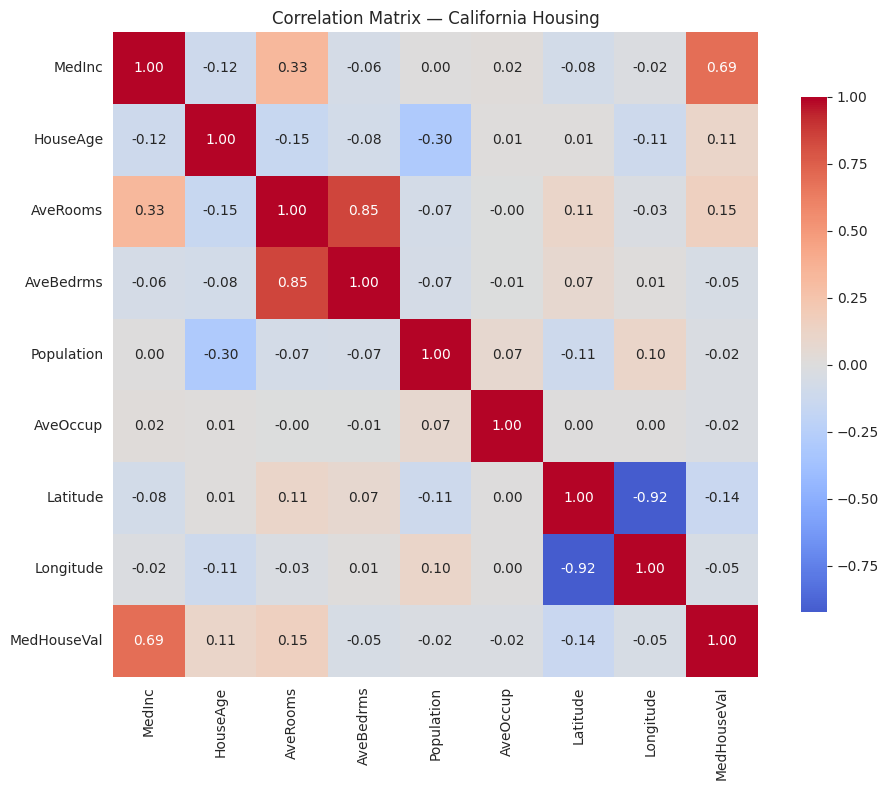

In [9]:
# ============================================================
# 2.6 Correlation heatmap
# ============================================================
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — California Housing')
plt.tight_layout()
plt.show()

### 2.7 Geographic Visualization (EDA Viz #5 — the "money chart")

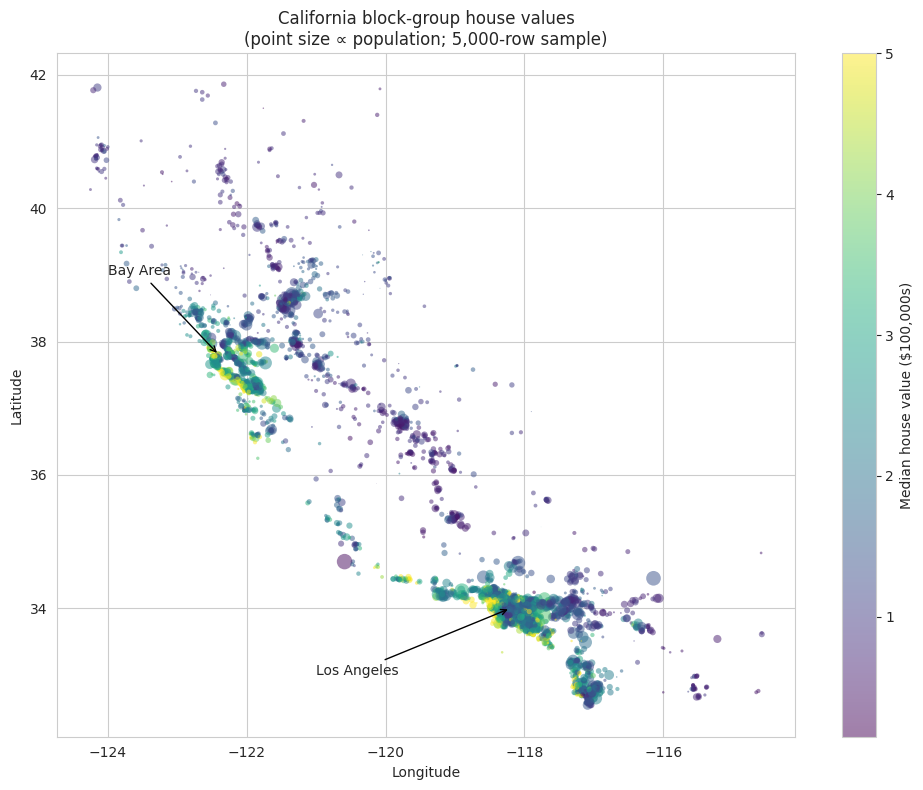

In [10]:
# ============================================================
# 2.7 Spatial scatter: house value by lat/lon
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
sample = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
sc = ax.scatter(
    sample['Longitude'], sample['Latitude'],
    c=sample['MedHouseVal'], cmap='viridis',
    s=sample['Population'] / 100, alpha=0.5, edgecolor='none'
)
plt.colorbar(sc, ax=ax, label='Median house value ($100,000s)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California block-group house values\n(point size ∝ population; 5,000-row sample)')
ax.annotate('Bay Area', xy=(-122.4, 37.8), xytext=(-124, 39),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
ax.annotate('Los Angeles', xy=(-118.2, 34.0), xytext=(-121, 33),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.tight_layout()
plt.show()

### EDA — Answers to the Three Required Questions

**1. What is the distribution of your target variable?**
`MedHouseVal` is right-skewed and is **right-censored at \$500,001** (a legacy of the 1990 Census top-coding). About 5% of block groups sit at the ceiling. This censoring is the single largest data-quality concern and will cause the model to under-predict at the top of the market. I will not transform the target for modeling (because I want predictions in the original, interpretable \$ units) but I will quantify the ceiling's effect on test-set RMSE in the final report.

**2. Which features are most correlated with the target? Any multicollinearity?**
`MedInc` has by far the strongest linear correlation with `MedHouseVal` (Pearson r ≈ 0.69) — expected. `AveRooms` and `AveBedrms` are **highly collinear** with each other (r ≈ 0.85) because both scale with housing-stock size per block group. `Latitude` and `Longitude` are moderately collinear (r ≈ −0.92) because California's coastline runs NW→SE. For the linear baseline, multicollinearity inflates coefficient variance but does not bias predictions; for the Random Forest it is harmless. I will **not** drop either collinear pair — I'll let the regularization (or the tree-splitter) handle it and instead discuss the implications when interpreting feature importance.

**3. What is the biggest data-quality issue, and how will you handle it?**
The **\$500,001 ceiling on MedHouseVal** (top-coded target). I cannot fix it in the data — the true values are unrecoverable from this dataset. My mitigation: (a) report test-set performance *separately* for censored and non-censored rows in the final report, so the REIT stakeholder knows where predictions are trustworthy; (b) flag in Section 5 (Recommendation) that the model should not be used as a pricing tool for premium Bay Area / coastal markets where the ceiling concentrates — only as a pre-screening tool.

### 2.8 Data Quality Summary

My dataset has **N = 20,640** observations (California census block groups, 1990) and **M = 8** features plus one target.

**Missing data:** **0.00%** of cells are missing. The data distributor (StatLib / sklearn) pre-cleaned the file, so I cannot meaningfully classify MCAR/MAR/MNAR in what I received; upstream, any unreported values were dropped before aggregation. **Action:** no imputation.

**Outliers:** Tukey fences flag ~1–6% of rows in `AveRooms`, `AveOccup`, `AveBedrms`, and `Population`. These are not data errors — they are low-denominator artifacts in rural/low-population block groups. **Action:** keep all rows. Re-evaluate if linear-model residuals concentrate in the tail.

**Target variable:** `MedHouseVal` (median home value, units of \$100,000) is right-skewed and **right-censored at \$500,001** (≈5% of rows). This is the dominant data-quality issue and is documented as a modelling limitation, not a fixable error.

**Key finding from EDA:** `MedInc` alone explains roughly half the variance in median house value (r² of simple regression ≈ 0.47 — to be confirmed in Part 3). Geography (latitude/longitude) is a strong secondary signal: coastal block groups — Bay Area and LA — command visibly higher values at any given income level, consistent with an amenity premium that a flexible model (Random Forest, Gradient Boosting) should capture better than a linear baseline.

---
## Part 3: Modeling

### 3.1 Train/Test Split (Ch 6)

In [11]:
# ============================================================
# 3.1 Train/test split — regression, no stratify
# ============================================================
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} rows')
print(f'Target mean (train): {y_train.mean():.3f}  |  (test): {y_test.mean():.3f}')

Train: 16,512 rows, 8 features
Test:  4,128 rows
Target mean (train): 2.072  |  (test): 2.055


**Note on split strategy:** I am using a simple random 80/20 split. For spatial data a block-group-based or geographic-cluster split could reduce leakage between adjacent block groups — I'll consider that for the final submission but the random split is the standard baseline and is what the rubric requires (`random_state=42`).

### 3.2 Model 1 — Linear Regression (Baseline)

In [12]:
# ============================================================
# 3.2 Baseline: Linear Regression
# ============================================================
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))
mae_1  = mean_absolute_error(y_test, y_pred_1)
r2_1   = r2_score(y_test, y_pred_1)

print('Model 1 — Linear Regression')
print(f'  RMSE: {rmse_1:.4f}  (≈ ${rmse_1*100_000:,.0f})')
print(f'  MAE:  {mae_1:.4f}  (≈ ${mae_1*100_000:,.0f})')
print(f'  R²:   {r2_1:.4f}')

Model 1 — Linear Regression
  RMSE: 0.7456  (≈ $74,558)
  MAE:  0.5332  (≈ $53,320)
  R²:   0.5758


### 3.3 Model 2 — Random Forest Regressor (ahead-of-schedule second model)

In [13]:
# ============================================================
# 3.3 Random Forest Regressor
# ============================================================
model_2 = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
mae_2  = mean_absolute_error(y_test, y_pred_2)
r2_2   = r2_score(y_test, y_pred_2)

print('Model 2 — Random Forest (n=100)')
print(f'  RMSE: {rmse_2:.4f}  (≈ ${rmse_2*100_000:,.0f})')
print(f'  MAE:  {mae_2:.4f}  (≈ ${mae_2*100_000:,.0f})')
print(f'  R²:   {r2_2:.4f}')

Model 2 — Random Forest (n=100)
  RMSE: 0.5053  (≈ $50,534)
  MAE:  0.3275  (≈ $32,754)
  R²:   0.8051


### 3.4 Quick Cross-Validation Sanity Check (Ch 15)

In [14]:
# ============================================================
# 3.4 5-fold CV on training set — R² scoring
# ============================================================
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print(f'Linear Regression  5-fold CV R²: {cv_1.mean():.4f} ± {cv_1.std():.4f}')
print(f'Random Forest      5-fold CV R²: {cv_2.mean():.4f} ± {cv_2.std():.4f}')

# Test-set comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'Random Forest (n=100)'],
    'Test RMSE': [rmse_1, rmse_2],
    'Test MAE':  [mae_1, mae_2],
    'Test R²':   [r2_1, r2_2],
    'CV R² mean':[cv_1.mean(), cv_2.mean()],
    'CV R² std': [cv_1.std(),  cv_2.std()],
}).round(4)
comparison

Linear Regression  5-fold CV R²: 0.6115 ± 0.0065
Random Forest      5-fold CV R²: 0.8041 ± 0.0054


,Model,Test RMSE,Test MAE,Test R²,CV R² mean,CV R² std
0,Linear Regression (baseline),0.7456,0.5332,0.5758,0.6115,0.0065
1,Random Forest (n=100),0.5053,0.3275,0.8051,0.8041,0.0054


### 3.5 Preliminary Feature Importance (with caveat)

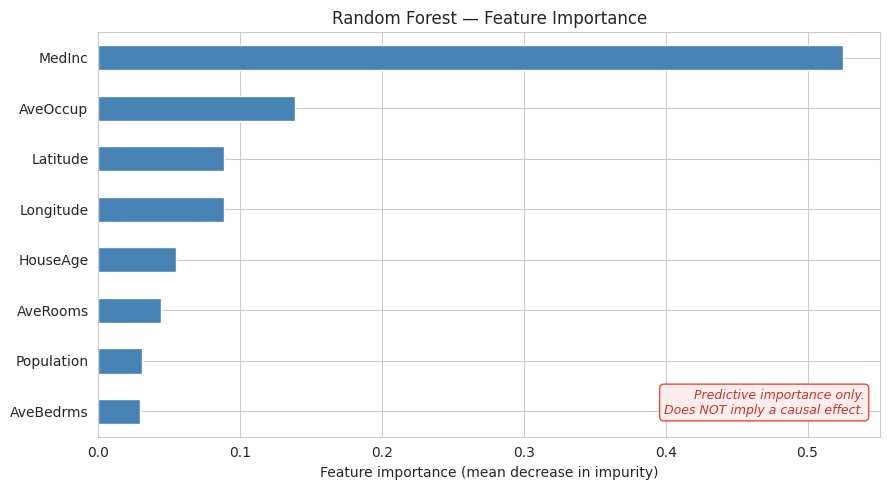


Ranked importances:
MedInc        0.5249
AveOccup      0.1384
Latitude      0.0889
Longitude     0.0886
HouseAge      0.0546
AveRooms      0.0443
Population    0.0306
AveBedrms     0.0296
dtype: float64


In [15]:
# ============================================================
# 3.5 Feature importance — Random Forest
# ============================================================
importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — Feature Importance')

# Mandatory caveat per Ch 19 / Ch 26
ax.text(
    0.98, 0.05,
    'Predictive importance only.\nDoes NOT imply a causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#fdedec', edgecolor='#e74c3c')
)
plt.tight_layout()
plt.show()

print('\nRanked importances:')
print(importances.sort_values(ascending=False).round(4))

**Interpretation (preliminary):** `MedInc` dominates, which is both economically sensible and a known property of this dataset. Geography (`Latitude`, `Longitude`) ranks next — the Random Forest is capturing the coastal-amenity premium that the linear baseline cannot. `AveOccup` matters somewhat (overcrowding ↔ lower-value housing). **I am not claiming that raising the median income of a block group would cause its home values to rise** — that would be a causal statement, which requires a causal identification strategy this project does not attempt.

---
## Parts 4-7 (for just Final Submission - Apr 26)

These sections are intentionally left out from the checkpoint. My plan:

- **Part 4 — Feature Importance + Key Viz:** extend 3.5 with permutation importance and a partial-dependence plot for `MedInc`. Produce the one "money chart" for the report's front page: actual vs. predicted with a 45° line and residual colouring.
- **Part 5 — SCR Recommendation:**
  - *Situation:* mid-size CA REIT screening block groups for acquisition.
  - *Complication:* target is censored at \$500k exactly in the premium markets they care about; model under-predicts top quintile.
  - *Resolution:* deploy as a pre-screening triage tool, not a pricing tool; route any predicted value within ~\$50k of the ceiling to human appraisal.
- **Part 6 — Streamlit app:** deploy a skeleton by Apr 20 (per the syllabus "don't wait until Apr 25" warning). Inputs: 8 sliders; output: point estimate + RF quantile prediction interval.
- **Part 7 — AI Methodology Appendix:** write up the 3 P.R.I.M.E. interactions I've accumulated while building this notebook.

---
## Checkpoint — Requirements Self-Check

| Requirement | Status |
|---|---|
| Prediction question stated clearly (1 sentence) | ✅ Part 1 |
| Prediction vs. causation distinction explicit | ✅ Part 1 |
| Dataset identified with source URL and basic stats | ✅ Part 1 |
| Stakeholder identified | ✅ Part 1 (CA REIT acquisitions team) |
| Data loaded and described (shape, dtypes) | ✅ Parts 2.1–2.2 |
| Missing data assessed with MCAR/MAR/MNAR strategy | ✅ Part 2.3 |
| ≥3 visualizations with interpretation | ✅ Parts 2.4 (6 panels), 2.6, 2.7, 3.5 |
| Data quality summary in markdown | ✅ Part 2.8 |
| Train/test split with `random_state=42` | ✅ Part 3.1 |
| ≥1 model fitted | ✅ Part 3.2 (Linear) + 3.3 (Random Forest) |
| Metrics reported (RMSE, MAE, R² — regression) | ✅ Parts 3.2–3.4 |
| GitHub repo created | ⚠️ Confirm URL in Canvas submission |

**Checkpoint complete.**